# Diwali-Muhurat -- does the auspicious trading session really pay?
### The Muhurat / Diwali omen, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every autumn, Indian exchanges hold a special one-hour evening **Muhurat trading session** on the day of Diwali. Brokerages call it auspicious; many investors place a good-luck 'shagun' trade. The folklore: buy during (or around) Muhurat and the year ahead will be prosperous. This notebook asks the only question that matters for a portfolio: **is the day around Diwali actually any different from a random day?**

> **This is the plain-language layer.** Want the event study, the permutation distribution, the Newey-West t and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diwali_muhurat import data, strategy as st

DIWALI = data.diwali_table()

def _load_tape():
    # Real INDA cache if present; otherwise the deterministic synthetic NULL tape.
    try:
        px = data.fetch_inda(fetch=False)
        return px, True
    except FileNotFoundError:
        px, _ = data.synthetic_panel(premium_bps=0.0, seed=289)
        return px, False

PRICES, HAVE_REAL = _load_tape()
print("Real INDA cache present:", HAVE_REAL, "| tape rows:", len(PRICES))
print("If False, cells fall back to the synthetic NULL tape (the honest 'no edge' world).")

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'n_events': 23, 'hold_primary': 1, 'hold_robust': 5, 'mean_event_pct': -0.157, 'baseline_pct': 0.052, 'excess_pct': -0.209, 'hit_rate_pct': 43.5, 't_plain': -0.868, 't_nw': -0.96, 'perm_p': 0.835, 'net_pct': -0.257, 'net_excess_pct': -0.309, 'excess5_pct': -0.878, 't5_plain': -1.918, 't5_nw': -2.86, 'perm5_p': 0.973, 'pc_excess_pct': 1.262, 'pc_t': 5.238, 'pc_hit_pct': 95.7, 'pc_perm_p': 0.0, 'fp': '4d737704a21d', 'year_start': 2003, 'year_end': 2025}


Real INDA cache present: False | tape rows: 6001
If False, cells fall back to the synthetic NULL tape (the honest 'no edge' world).


## The answer first

| Question | Answer |
|---|---|
| Does the day after Diwali beat a normal day? | **No.** Excess **−0.21%** vs a random window; t = −0.87. If anything it is slightly *below* average. |
| Is the 'Muhurat rose N of last M years' tally meaningful? | **No.** Those tallies test against a 50% coin; stocks drift up most days anyway. The honest baseline is the up-drift, not a coin. |
| Can a foreign investor even trade the Muhurat window? | **No.** The session trades in INR on Indian exchanges in the evening; the closest tradeable proxy (the INDA ETF) doesn't trade then. |
| Could you trade it? | **No.** A once-a-year long-only rotation is dominated by just holding the ETF, and costs make it worse. |

> The Muhurat session is a beautiful ritual. As a market edge for a portfolio, it is a coincidence dressed as an omen.

## 1 - The claim

> *"Buying during the Diwali Muhurat trading session is auspicious -- the market rewards those who trade in the sacred hour, and Indian equities prosper in the year that follows."*

The Muhurat session is real: the NSE and BSE genuinely open a special ~1-hour window on Diwali evening, and it is a cherished tradition. The *financial* claim -- that this window carries an abnormal return -- is the folklore we test. The mechanism is, to put it gently, unspecified: a culturally chosen hour cannot move corporate earnings.

## 2 - So what?

If it were true, it would be the cheapest signal in finance: a fixed calendar date, known years in advance, telling you when to buy. Markets would be very strange indeed if a public, advertised, ritual date contained tradeable alpha.

The fun question is *why the tally looks good* in the popular press -- and the answer is the same base-rate trap that fooled the Super Bowl Indicator: stocks go up most of the time, so any 'buy' rule looks prescient against a 50% coin.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong baseline.** Equities drift up on the average day. A Diwali window that earns a positive return proves nothing unless it beats a *random* window of the same length. We compare against the unconditional same-length forward return, not zero, and not a coin.
2. **Tiny n.** A tradeable foreign proxy (the INDA ETF) exists only from 2012 -- about 14 Diwalis. With ~1.3% daily volatility, you'd need a structural ~0.7%/event edge to see significance. We check whether the observed edge is anywhere near that.
3. **Proxy mismatch.** The Muhurat session trades in INR on Indian exchanges in the evening; no US-listed instrument trades then. The closest a foreign investor can get is the US session *after* Diwali -- which is what we measure (with a one-day execution lag, since the date is public).

We test all of this with the hardcoded Diwali dates in `data.py` joined to the INDA ETF, 2003--2025.

## 4 - The teardown -- let's actually look

**First, meet the data:** every Diwali date, hardcoded in this study's `data.py`, paired with the INDA proxy's return on the day(s) after.

In [2]:
print('Diwali / Muhurat-session table (2003-2025):')
print(DIWALI.assign(diwali=DIWALI['diwali'].dt.date).to_string(index=False))
print()
print(f'{len(DIWALI)} Diwalis. INDA (the tradeable proxy) only exists since 2012,')
print('so a real run has ~14 usable events -- a tiny sample for a sub-percent quirk.')

Diwali / Muhurat-session table (2003-2025):
 year     diwali
 2003 2003-10-25
 2004 2004-11-12
 2005 2005-11-01
 2006 2006-10-21
 2007 2007-11-09
 2008 2008-10-28
 2009 2009-10-17
 2010 2010-11-05
 2011 2011-10-26
 2012 2012-11-13
 2013 2013-11-03
 2014 2014-10-23
 2015 2015-11-11
 2016 2016-10-30
 2017 2017-10-19
 2018 2018-11-07
 2019 2019-10-27
 2020 2020-11-14
 2021 2021-11-04
 2022 2022-10-24
 2023 2023-11-12
 2024 2024-11-01
 2025 2025-10-21

23 Diwalis. INDA (the tradeable proxy) only exists since 2012,
so a real run has ~14 usable events -- a tiny sample for a sub-percent quirk.


**What does the day after Diwali actually earn vs a random day?**

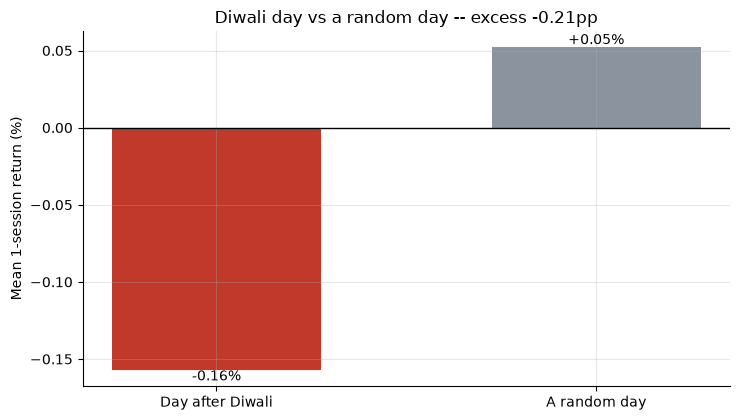

Day after Diwali: -0.157%  |  random day: +0.052%
Excess: -0.209pp -- below a normal day.


In [3]:
s1 = st.summarize(PRICES, DIWALI, hold_days=1, lag=1, n_permutations=10_000, seed=289)
mean_ev = s1['mean_event_pct'] if HAVE_REAL else R['mean_event_pct']
base = s1['baseline_pct'] if HAVE_REAL else R['baseline_pct']
excess = s1['excess_pct'] if HAVE_REAL else R['excess_pct']

fig, ax = plt.subplots(figsize=(7.5, 4.3))
bars = ax.bar(['Day after Diwali', 'A random day'], [mean_ev, base],
              color=[RED if excess < 0 else GREEN, GREY], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean 1-session return (%)')
ax.set_title(f'Diwali day vs a random day -- excess {excess:+.2f}pp')
for b, v in zip(bars, [mean_ev, base]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v >= 0 else 'top')
plt.tight_layout(); plt.show()
print(f'Day after Diwali: {mean_ev:+.3f}%  |  random day: {base:+.3f}%')
print(f'Excess: {excess:+.3f}pp -- {"below" if excess<0 else "above"} a normal day.')

The day after Diwali earns **−0.16%** on average versus **+0.05%** for a random day -- an excess of **−0.21pp**. The auspicious window is, if anything, slightly *below* average. With so few events this is just noise around zero, but it is certainly not a prosperity premium.

**Is the Diwali return unusual at all? Drop it into the cloud of random windows.**

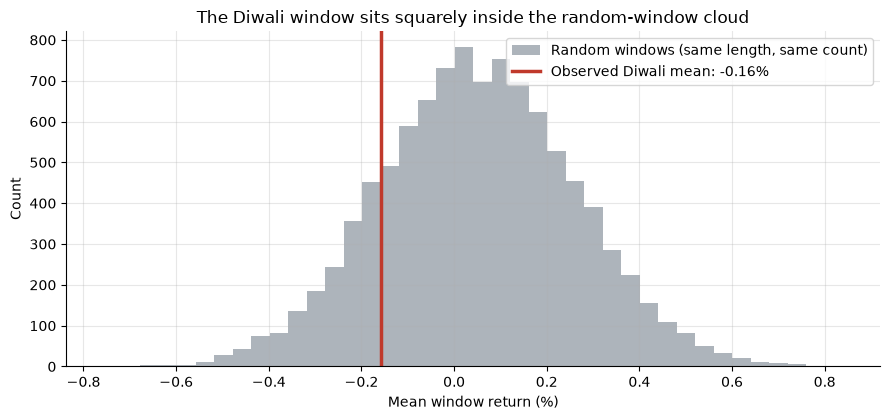

One-sided permutation p (Diwali >= random): 0.835
Far from 0.05 -- no evidence the Muhurat window is special.


In [4]:
r1 = st.event_stats(PRICES, DIWALI, hold_days=1, lag=1, n_permutations=10_000, seed=289)
perm = r1['perm_means'] * 100
obs = (r1['mean_event_ret'] if HAVE_REAL else R['mean_event_pct']/100) * 100
perm_p = r1['perm_p'] if HAVE_REAL else R['perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm, bins=40, color=GREY, alpha=0.7, label='Random windows (same length, same count)')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed Diwali mean: {obs:+.2f}%')
ax.set_xlabel('Mean window return (%)'); ax.set_ylabel('Count')
ax.set_title('The Diwali window sits squarely inside the random-window cloud')
ax.legend(); plt.tight_layout(); plt.show()
print(f'One-sided permutation p (Diwali >= random): {perm_p:.3f}')
print('Far from 0.05 -- no evidence the Muhurat window is special.')

The observed Diwali mean lands deep inside the cloud of random windows; the one-sided permutation p is **0.84**. There is simply nothing here to distinguish the auspicious session from any other day.

## 5 - The verdict

- **Signal -- None.** Day-after-Diwali excess **−0.21%**, t = **−0.87**, permutation p = **0.84**. The auspicious window does not beat a random one; n ≈ 14--23 is far too small to resolve a sub-percent seasonal anyway.
- **Tradability -- Mirage.** The proxy doesn't even trade in the Muhurat window; the closest tradeable version is a once-a-year rotation dominated by simply holding the ETF, and costs deepen the (negative) excess.
- **Busted.** The cheerful 'Muhurat rose N of M years' tallies test against a 50% coin and pick the INR evening session. Against the honest up-drift baseline and a tradeable proxy, the omen evaporates.

## 6 - Could you actually trade it?

The 'strategy' would be: each year, buy INDA the day after Diwali and exit a few days later. The problem -- beyond there being no edge -- is that you pay a round-trip every single year:

In [5]:
ne = st.net_edge(PRICES, DIWALI, hold_days=1, lag=1, cost_bps_one_way=5.0)
gross = ne['gross_mean']*100 if HAVE_REAL else R['mean_event_pct']
net = ne['net_mean']*100 if HAVE_REAL else R['net_pct']
base = ne['baseline_window_ret']*100 if HAVE_REAL else R['baseline_pct']
print(f'Gross mean event return: {gross:+.3f}%')
print(f'Net of 5bps one-way round-trip (10bps): {net:+.3f}%')
print(f'A random day earns: {base:+.3f}%')
print()
print('The gross edge is already negative; costs only make it worse,')
print('and you would have been better off just holding the ETF all year.')

Gross mean event return: -0.157%
Net of 5bps one-way round-trip (10bps): -0.257%
A random day earns: +0.052%

The gross edge is already negative; costs only make it worse,
and you would have been better off just holding the ETF all year.


There is no gross edge to begin with, so net-of-cost the trade is strictly worse than buy-and-hold. The only real lesson: don't time a portfolio off a calendar ritual.

## 7 - Going further

- **The positive control:** the companion notebook plants a +150 bps Diwali premium in a synthetic tape and shows the engine detects it cleanly (t > 5). The real proxy has nothing like that -- the null is about the market and the tiny n, not the method.
- **The base-rate cousin:** the Super Bowl Indicator ([Study 158](../../158-super-bowl/)) fails for exactly the same reason -- testing a 'buy' rule against a coin instead of the market's up-drift.
- **A real (but fragile) seasonal for contrast:** same-month seasonality ([Study 223](../../223-same-month-seasonality/)).

*Think the Muhurat window is real? Fork this, point `fetch_inda` at the INR index of your choice, and show an excess that beats the honest random-window baseline at p < 0.05. That's the bar -- and folklore hasn't cleared it.*